Import the dataset

In [1]:
import kagglehub
from pandas.core._numba import kernels

# Download latest version
path = kagglehub.dataset_download("yashdogra/speech-commands")

print("Path to dataset files:", path)

C:\Users\leyan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\leyan\.cache\kagglehub\datasets\yashdogra\speech-commands\versions\1


## Train SVM model
extract 500 random samples from each class in a temporary directory and train a SVM model using pyAudioAnalysis.

In [35]:
import numpy as np
from pathlib import Path
import random
import shutil
import tempfile
from pyAudioAnalysis import audioTrainTest as aT
import class_adapter as ca
import csv
import wave
import math

In [ ]:
# np.Inf was removed in the NumPy 2.0 release. Use np.inf instead.
if not hasattr(np, "Inf"):
    np.Inf = np.inf
if not hasattr(np, "NaN"):
    np.NaN = np.nan

## Split training set and test set

In [22]:
base = Path(path)

class_splits = {}
train_samples = 500
test_samples = 100

for folder in sorted(base.iterdir()):
    if folder.is_dir() and folder.name != "_background_noise_":
        speaker_groups = {}

        for wav in sorted(folder.glob("*.wav")):
            speaker_id = wav.stem.split("_nohash_")[0]
            speaker_groups.setdefault(speaker_id, []).append(wav)

        speakers = sorted(speaker_groups)
        if len(speakers) < test_samples:
            raise ValueError(f"{folder.name}: servono almeno {test_samples} speaker, trovati {len(speakers)}")

        test_speakers = speakers[-test_samples:]
        train_speakers = speakers[:-test_samples]

        train_selected = []
        round_index = 0
        while len(train_selected) < train_samples:
            made_progress = False
            for speaker_id in train_speakers:
                wavs = speaker_groups[speaker_id]
                if round_index < len(wavs):
                    train_selected.append(wavs[round_index])
                    made_progress = True
                    if len(train_selected) == train_samples:
                        break
            if not made_progress:
                break
            round_index += 1

        if len(train_selected) != train_samples:
            raise ValueError(f"{folder.name}: disponibili solo {len(train_selected)} campioni per il train")

        test_selected = [speaker_groups[speaker_id][0] for speaker_id in test_speakers]

        class_splits[folder.name] = {
            "train": train_selected,
            "test": test_selected,
        }

### Create folders for train and test sets

In [24]:
tmp_train_root = Path(tempfile.mkdtemp())
tmp_test_root = Path(tempfile.mkdtemp())

train_dirs = []
test_dirs = []

for class_name, split in class_splits.items():
    train_dir = tmp_train_root / class_name
    test_dir = tmp_test_root / class_name
    train_dir.mkdir(parents=True, exist_ok=True)
    test_dir.mkdir(parents=True, exist_ok=True)

    for wav in split["train"]:
        shutil.copy2(wav, train_dir / wav.name)

    for wav in split["test"]:
        shutil.copy2(wav, test_dir / wav.name)

    train_dirs.append(str(train_dir))
    test_dirs.append(str(test_dir))

#print(train_dirs)
#print(test_dirs)

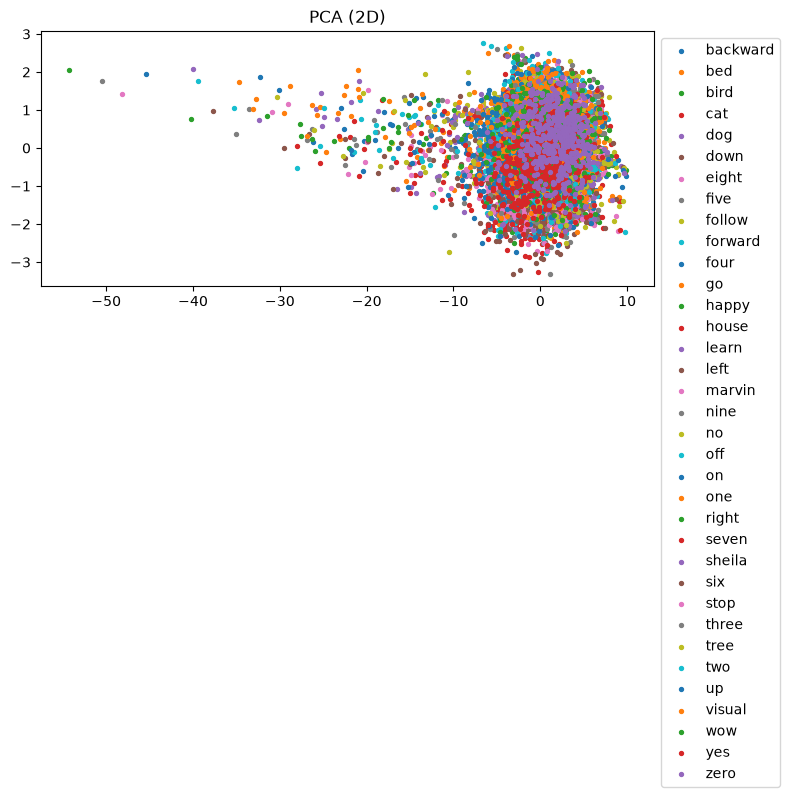

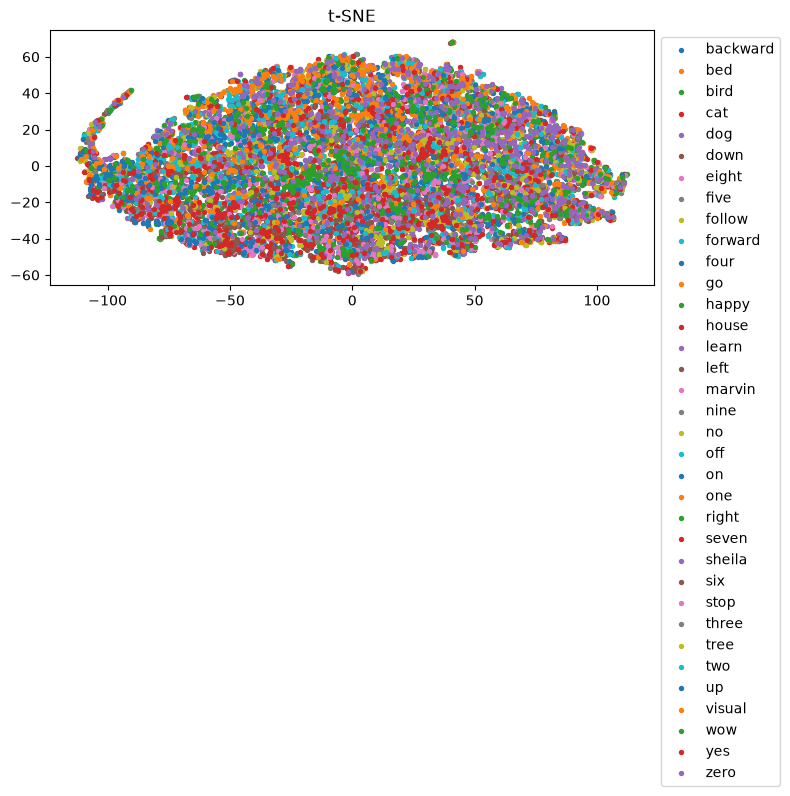

feature vector length set: [68] -> used length: 68


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from pyAudioAnalysis import audioBasicIO, ShortTermFeatures
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# fallback import per diverse versioni di pyAudioAnalysis
from pyAudioAnalysis import audioBasicIO
try:
    from pyAudioAnalysis import audioFeatureExtraction as aF
    def extract_short_term(x, Fs, win_s, step_s):
        return aF.stFeatureExtraction(x, Fs, int(win_s*Fs), int(step_s*Fs))
except Exception:
    from pyAudioAnalysis import ShortTermFeatures as aF
    def extract_short_term(x, Fs, win_s, step_s):
        return aF.feature_extraction(x, Fs, int(win_s*Fs), int(step_s*Fs))

import numpy as np

def file_feat(fp, win_s=0.050, step_s=0.025):
    Fs, x = audioBasicIO.read_audio_file(fp)
    if x.ndim > 1:
        x = x.mean(axis=1)
    F = extract_short_term(x, Fs, win_s, step_s)
    # if tuple/list, take first element (common API shape)
    if isinstance(F, (list, tuple)):
        F = F[0]
    F = np.asarray(F, dtype=object) if F is None else np.asarray(F)
    if F.ndim == 1:
        return F.astype(float)
    # try to make 2D (features x frames)
    if F.dtype == object:
        rows = []
        for r in F:
            a = np.asarray(r).flatten()
            rows.append(a if a.size else np.zeros(1))
        # pad rows to same length then mean over frames axis
        maxlen = max(len(r) for r in rows)
        mat = np.vstack([np.pad(r, (0, maxlen-len(r))) for r in rows])
        return mat.mean(axis=1)
    else:
        return np.mean(F, axis=1)

# build X (file-level features) with safety for unequal vector lengths
feats = [file_feat(f) for f in files]
lengths = [f.shape[0] for f in feats]
if len(set(lengths)) != 1:
    # pad/truncate to max length
    maxlen = max(lengths)
    feats = [np.pad(f, (0, maxlen - f.shape[0])) if f.shape[0]<maxlen else f[:maxlen] for f in feats]

X = np.vstack(feats)
y = np.array(labels)

# PCA + t-SNE plot
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

p2 = PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(8,6))
for cl in np.unique(y):
    idx = np.where(y==cl)
    plt.scatter(p2[idx,0], p2[idx,1], s=8, label=cl)
plt.title("PCA (2D)"); plt.legend(bbox_to_anchor=(1,1)); plt.tight_layout(); plt.show()

tsne = TSNE(n_components=2, init='pca', random_state=0, perplexity=30)
t2 = tsne.fit_transform(X)
plt.figure(figsize=(8,6))
for cl in np.unique(y):
    idx = np.where(y==cl)
    plt.scatter(t2[idx,0], t2[idx,1], s=8, label=cl)
plt.title("t-SNE"); plt.legend(bbox_to_anchor=(1,1)); plt.tight_layout(); plt.show()

# quick diagnostics
print("feature vector length set:", sorted(set(lengths)) , "-> used length:", X.shape[1])

Train the SVM model using pyAudioAnalysis. The model will be saved as "svm_model".

In [3]:
aT.extract_features_and_train(
    train_dirs,
    1.0, 1.0,
    aT.shortTermWindow, aT.shortTermStep,
    "svm_rbf",
    "svm_model",
    True
)

aT.extract_features_and_train(
    train_dirs,
    1.0, 1.0,
    aT.shortTermWindow, aT.shortTermStep,
    "gradientboosting",
    "gbc_model",
    True
)

Analyzing file 1 of 500: C:\Users\leyan\AppData\Local\Temp\tmp5ci_yjpz\backward\017c4098_nohash_3.wav
Analyzing file 2 of 500: C:\Users\leyan\AppData\Local\Temp\tmp5ci_yjpz\backward\042a8dde_nohash_2.wav
Analyzing file 3 of 500: C:\Users\leyan\AppData\Local\Temp\tmp5ci_yjpz\backward\0585b66d_nohash_1.wav
Analyzing file 4 of 500: C:\Users\leyan\AppData\Local\Temp\tmp5ci_yjpz\backward\0585b66d_nohash_2.wav
Analyzing file 5 of 500: C:\Users\leyan\AppData\Local\Temp\tmp5ci_yjpz\backward\067f61e2_nohash_2.wav
Analyzing file 6 of 500: C:\Users\leyan\AppData\Local\Temp\tmp5ci_yjpz\backward\067f61e2_nohash_4.wav
Analyzing file 7 of 500: C:\Users\leyan\AppData\Local\Temp\tmp5ci_yjpz\backward\06f6c194_nohash_0.wav
Analyzing file 8 of 500: C:\Users\leyan\AppData\Local\Temp\tmp5ci_yjpz\backward\08ab231c_nohash_0.wav
Analyzing file 9 of 500: C:\Users\leyan\AppData\Local\Temp\tmp5ci_yjpz\backward\0a2b400e_nohash_2.wav
Analyzing file 10 of 500: C:\Users\leyan\AppData\Local\Temp\tmp5ci_yjpz\backward\0

C:\Users\leyan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Param = 0.00100 - classifier Evaluation Experiment 2 of 3


C:\Users\leyan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Param = 0.00100 - classifier Evaluation Experiment 3 of 3


...

C:\Users\leyan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Param = 20.00000 - classifier Evaluation Experiment 3 of 3


C:\Users\leyan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


		backward			bed			bird			cat			dog			down			eight			five			follow			forward			four			go			happy			house			learn			left			marvin			nine			no			off			on			one			right			seven			sheila			six			stop			three			tree			two			up			visual			wow			yes			zero		OVERALL
	C	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	PRE	REC	f1	ACC	f1
	0.001	30.9	42.9	35.9	30.4	48.6	37.4	56.7	47.5	51.7	45.2	50.6	47.8	26.1	31.3	28.5	18.9	17.6	18.2	48.2	51.5	49.8	34.7	24.3	28.6	40.2	43.3	41.7	29.5	37.3	32.9	47.4	36.7	41.4	33.6	20.7	25.6	50.0	47.9	48.9	57.1	60.9	59.0	34.4	34.4	34.4	36.2	38.2	37.2	23.5	34.8	28.1	32.9	34.0	33.4	25.8	25.6	25.7	42.0	41.2	41.6	40.7	21.6	28.2	28.9	25.7	27.2	34.9	19.0

C:\Users\leyan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Load the trained SVM model if it exists.

In [3]:
aT.load_model("svm_model", False)

(SVC(C=np.float64(0.5), gamma='auto', kernel='linear', probability=True),
 array([ 1.39845485e-01,  2.10429123e-02,  2.95218848e+00,  2.32874943e-01,
         2.14017122e-01,  9.98740848e-01,  1.35850325e-02,  2.28372809e-01,
        -3.06885461e+01,  1.88989746e+00, -1.02263706e-01,  1.38699901e-01,
        -2.66173467e-02,  8.97639799e-02, -5.89108013e-03,  1.39509546e-02,
        -7.24662174e-04, -1.48524172e-02, -4.37037513e-02,  1.78364385e-03,
        -3.58414441e-02,  1.49071071e-02,  5.18127441e-03,  3.19314972e-02,
         1.25157235e-02,  2.24767443e-02,  9.71919166e-03,  4.42293803e-02,
         3.58749257e-03,  6.89048076e-03,  1.30803387e-02,  3.15308530e-02,
         5.88361031e-03,  2.65927080e-02, -8.77996965e-04,  3.53363604e-04,
         5.96159244e-03, -1.68049862e-03, -3.87805814e-04, -5.75743023e-03,
         5.92718925e-04, -2.50169244e-03,  1.24652150e-01,  1.91280011e-02,
        -3.23890045e-03,  5.26729906e-05, -1.24523473e-03,  1.64350919e-03,
        -7.441

###

In [36]:
def read_wav(path):
    with wave.open(str(path), "rb") as wf:
        sr = wf.getframerate()
        audio = np.frombuffer(wf.readframes(wf.getnframes()), dtype=np.int16).astype(np.float32)
    return sr, audio

def write_wav(path, sr, audio):
    audio = np.clip(audio, -32768, 32767).astype(np.int16)
    with wave.open(str(path), "wb") as wf:
        wf.setnchannels(1)
        wf.setsampwidth(2)
        wf.setframerate(sr)
        wf.writeframes(audio.tobytes())

def add_fixed_noise(clean_path, noise_path, out_path, noise_level=0.2):
    sr, clean = read_wav(clean_path)
    _, noise = read_wav(noise_path)
    if len(noise) < len(clean):
        reps = math.ceil(len(clean)/len(noise))
        noise = np.tile(noise, reps)
    start = random.randint(0, max(0, len(noise)-len(clean)))
    noise_segment = noise[start:start+len(clean)]
    noisy = clean + noise_level * noise_segment
    write_wav(out_path, sr, noisy)

def add_intermittent_noise(clean_path, noise_path, out_path, noise_level=0.2, segments_per_second=10, noisy_segments=5):
    # noisy_segments chosen equidistribuiti within each second
    sr, clean = read_wav(clean_path)
    _, noise = read_wav(noise_path)
    if len(noise) < len(clean):
        reps = math.ceil(len(clean)/len(noise))
        noise = np.tile(noise, reps)
    start = random.randint(0, max(0, len(noise)-len(clean)))
    noise = noise[start:start+len(clean)]
    noisy = clean.copy()
    seg_len = max(1, sr // segments_per_second)
    # choose equidistributed active segment indices within a 1-second block
    active = np.linspace(0, segments_per_second-1, noisy_segments, dtype=int)
    total_segments = math.ceil(len(clean)/seg_len)
    for seg in range(total_segments):
        s = seg * seg_len
        e = min(s + seg_len, len(clean))
        if (seg % segments_per_second) in active:
            noisy[s:e] = clean[s:e] + noise[s:e] * noise_level
    write_wav(out_path, sr, noisy)

# --- generate folders: one fixed and one intermittent per noise file ---
base = Path(path)
noise_files = sorted((base / "_background_noise_").glob("*.wav"))

noisy_fixed_dirs = {}        # noise_name -> list of class folders (paths)
noisy_intermittent_dirs = {}

for noise_file in noise_files:
    fixed_root = Path(tempfile.mkdtemp(prefix=f"{noise_file.stem}_fixed_"))
    inter_root = Path(tempfile.mkdtemp(prefix=f"{noise_file.stem}_inter_"))
    fixed_class_dirs = []
    inter_class_dirs = []

    for class_name, split in class_splits.items():
        fixed_class = fixed_root / class_name
        inter_class = inter_root / class_name
        fixed_class.mkdir(parents=True, exist_ok=True)
        inter_class.mkdir(parents=True, exist_ok=True)

        for wav in split["test"]:
            add_fixed_noise(wav, noise_file, fixed_class / wav.name, noise_level=0.2)
            add_intermittent_noise(wav, noise_file, inter_class / wav.name,
                                   noise_level=0.2, segments_per_second=10, noisy_segments=5)

        fixed_class_dirs.append(str(fixed_class))
        inter_class_dirs.append(str(inter_class))

    noisy_fixed_dirs[noise_file.stem] = fixed_class_dirs
    noisy_intermittent_dirs[noise_file.stem] = inter_class_dirs

# noisy_fixed_dirs and noisy_intermittent_dirs are ready to feed into the classifier loop.

In [37]:
model_name = "svm_model"
clf_type = "svm"

noise_sets = {
    "fixed": noisy_fixed_dirs,
    "intermittent": noisy_intermittent_dirs,
}

all_results = {}

class_names = list(class_splits.keys())

for noise_type, noise_dict in noise_sets.items():
    for noise_name, class_dirs in noise_dict.items():
        results = {cn: {"correct": 0, "wrong": 0, "total": 0} for cn in class_names}

        for class_name, class_dir in zip(class_names, class_dirs):
            for wav_path in Path(class_dir).glob("*.wav"):
                try:
                    pred_raw = aT.file_classification(str(wav_path), model_name, clf_type)[0]
                except Exception as e:
                    print(f"Error classifying {wav_path}: {e}")
                    continue

                # normalize predicted label: if numeric -> map to class name
                if isinstance(pred_raw, (int, float)):
                    pred_label = ca.adapter(pred_raw)
                else:
                    pred_label = pred_raw

                results[class_name]["total"] += 1
                if pred_label == class_name:
                    results[class_name]["correct"] += 1
                else:
                    results[class_name]["wrong"] += 1

        all_results[(noise_type, noise_name)] = results

In [38]:
csv_name = f"{model_name}_noisy_results.csv"
with open(csv_name, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["noise_type", "noise_name", "class_name", "correct", "wrong", "total", "accuracy"])
    for (noise_type, noise_name), results in all_results.items():
        for class_name, stats in results.items():
            total = stats["total"]
            acc = stats["correct"] / total if total else 0
            writer.writerow([noise_type, noise_name, class_name, stats["correct"], stats["wrong"], total, acc])

print("Done. Results saved to", csv_name)

Done. Results saved to svm_model_noisy_results.csv


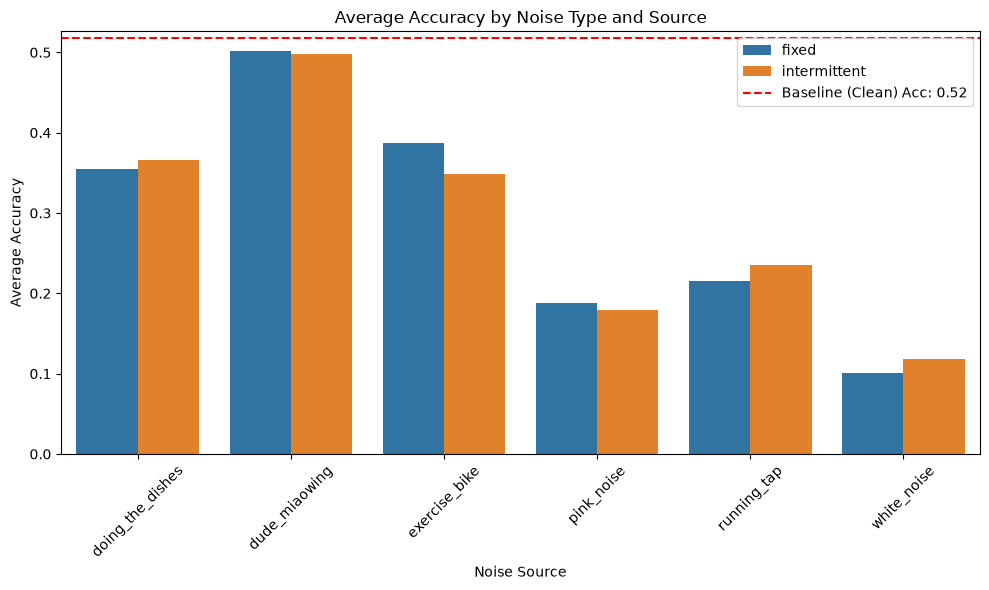

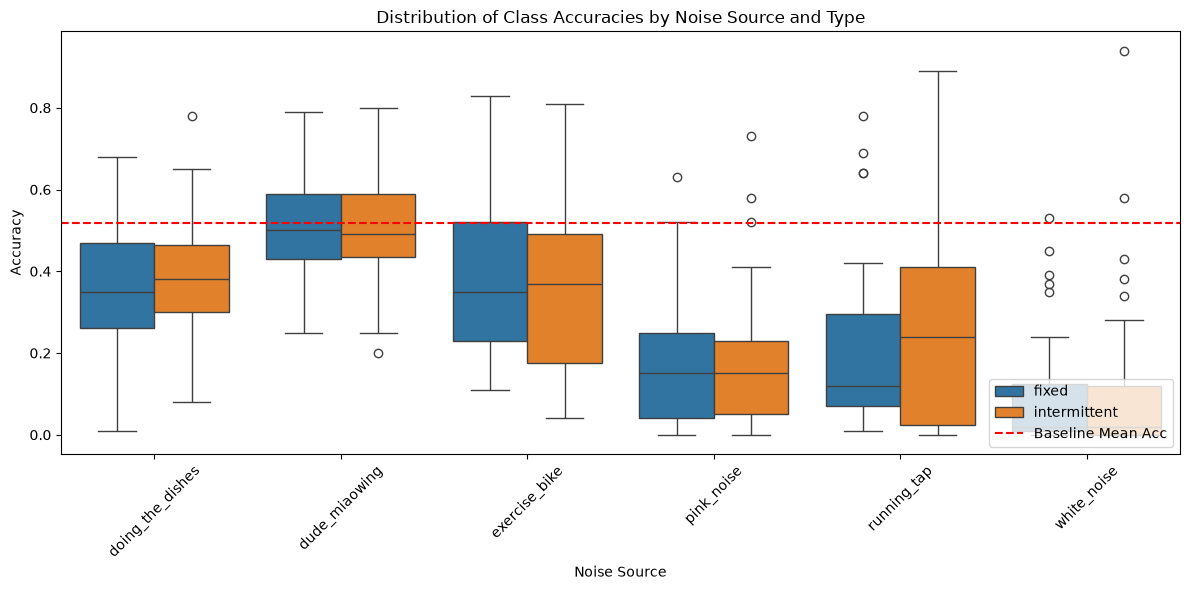

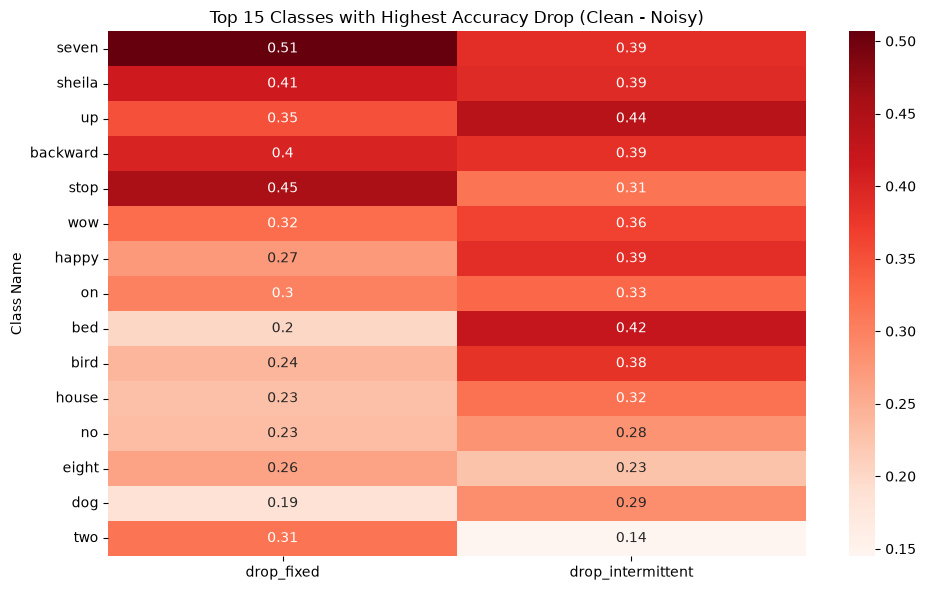

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Caricamento dei dati
df_clean = pd.read_csv('svm_model_results.csv')
df_noisy = pd.read_csv('svm_model_noisy_results.csv')

# Calcolo dell'accuratezza media di base (sui dati puliti)
baseline_acc = df_clean['accuracy'].mean()

# ==========================================
# GRAFICO 1: Bar Plot (Average Accuracy by Noise Type and Source)
# ==========================================
# Aggreghiamo i dati rumorosi per tipo e nome del rumore
agg_noise = df_noisy.groupby(['noise_type', 'noise_name'])['accuracy'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=agg_noise, x='noise_name', y='accuracy', hue='noise_type')
plt.axhline(baseline_acc, color='red', linestyle='--', label=f'Baseline (Clean) Acc: {baseline_acc:.2f}')
plt.title('Average Accuracy by Noise Type and Source')
plt.ylabel('Average Accuracy')
plt.xlabel('Noise Source')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('accuracy_by_noise.png')
# plt.show() # Decommenta per visualizzare a schermo invece di salvare

# ==========================================
# GRAFICO 2: Boxplot (Distribution of Accuracies across classes)
# ==========================================
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_noisy, x='noise_name', y='accuracy', hue='noise_type')
plt.axhline(baseline_acc, color='red', linestyle='--', label='Baseline Mean Acc')
plt.title('Distribution of Class Accuracies by Noise Source and Type')
plt.ylabel('Accuracy')
plt.xlabel('Noise Source')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('boxplot_accuracy.png')
# plt.show() # Decommenta per visualizzare a schermo invece di salvare

# ==========================================
# GRAFICO 3: Heatmap (Accuracy drop compared to baseline)
# ==========================================
# Prepariamo i dati per confrontare l'accuratezza pulita con quella rumorosa per ogni classe
class_acc = df_clean[['class_name', 'accuracy']].rename(columns={'accuracy': 'clean_acc'})
noisy_class_acc = df_noisy.groupby(['class_name', 'noise_type'])['accuracy'].mean().unstack().reset_index()

# Uniamo i dataset
merged_acc = pd.merge(class_acc, noisy_class_acc, on='class_name')

# Calcoliamo il calo di performance
merged_acc['drop_fixed'] = merged_acc['clean_acc'] - merged_acc['fixed']
merged_acc['drop_intermittent'] = merged_acc['clean_acc'] - merged_acc['intermittent']

# Ordiniamo per trovare le 15 classi più colpite (peggior calo medio)
merged_acc['avg_drop'] = (merged_acc['drop_fixed'] + merged_acc['drop_intermittent']) / 2
merged_acc_sorted = merged_acc.sort_values(by='avg_drop', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.heatmap(
    merged_acc_sorted[['drop_fixed', 'drop_intermittent']].set_index(merged_acc_sorted['class_name']),
    annot=True,
    cmap='Reds'
)
plt.title('Top 15 Classes with Highest Accuracy Drop (Clean - Noisy)')
plt.ylabel('Class Name')
plt.tight_layout()
plt.savefig('heatmap_accuracy_drop.png')
# plt.show() # Decommenta per visualizzare a schermo invece di salvare